## Apresentação ✒️

Notebook destinado ao estudo da elaboração de um modelo que consiga classificar em função das features (caraterísticas) que se relacionam a um perfil do cliente classificar se um cliente qualquer irá realizar churn ou não churn. Churn é o termo em que se dá para pessoas que deixam de ser clientes de uma empresa, não passando mais consumir seus produtos oferecidos e, com isso, impactando negativamente na geração da receita da empresa. Um dos grandes problemas desse cenário é que ele pode engendrar não apenas uma perda do cliente que deixa de contribuir com os ganhos da empresa, mas também de outros em potencial a partir dele, gerando um certo efeito multiplicativo de perda : um cliente que deixa de consumir produtos da empresa pode falar para os seus pares fazerem o mesmo. 

Em virtude disso, uma frequente aplicação de modelos de machine learning no mercado se dá em razão de conseguir identificar quais são as features que denotam um cliente que pode realizar churn em potencial e identificá-los como forma de se precaverem e/ou elaborarem políticas que visam o arrefecimento desse tipo de desligamento. Como se trata de um contexto de classificação, para tanto será implementado os principais modelos de classificação disponíveis e depois irei comparar qual deles melhor performa para serem provisionados para a empresa. A métrica que servirá de limiar de decisão será a f1-score, com consideração complementar da matriz de confusão e ROC-AUC, uma vez que em tais cenários o uso da acurácia se torna contraproducente, dado que a frequência de churn (espera-se) é menor do que o não churn, representando um desbalanceamento nas label, portanto. Para entender melhor sobre essa cosnideração e demais métricas de modelos de machine learning, ler o artigo a seguir : [Métricas para modelos de ML](https://medium.com/@brunoloducca15/métricas-de-avaliação-para-machine-learning-249f16d104da) . 


### Library

In [56]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import math

import matplotlib.pyplot as plt
import optuna
import pandas as pd
import seaborn as sns
from pandas import DataFrame
from scipy.stats.mstats import winsorize
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (f1_score, make_scorer, precision_score,
                             recall_score, roc_curve, auc, classification_report)

from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     train_test_split)

from sklearn.preprocessing import StandardScaler

### Carregando o dataset

In [8]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.shape

(10000, 14)

### Verificando a integridade do dataset

In [10]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [13]:
df.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

No dataset encontra-se três dados do tipo categórico, que deverão ser transformados caso sejam passados para os modelos de ML considerados. Dentre eles, a priori, o único que parece importar é a feature `Gender`, de modo que os demais outros não necessariamente, em especial a feature `Surname`.

### Legenda das features relevantes

| Feature            | Descrição                                                                 |
|--------------------|---------------------------------------------------------------------------|
| `CreditScore`      | Pontuação de crédito do cliente (quanto maior, melhor o histórico financeiro). |
| `Geography`        | País de residência do cliente (ex: França, Alemanha, Espanha).            |
| `Gender`           | Gênero do cliente (`Male` ou `Female`).                                   |
| `Age`              | Idade do cliente em anos.                                                 |
| `Tenure`           | Quantidade de anos que o cliente tem conta no banco.                      |
| `Balance`          | Saldo atual na conta do cliente.                                          |
| `NumOfProducts`    | Número de produtos bancários utilizados (ex: cartão, conta conjunta, etc).|
| `HasCrCard`        | Possui cartão de crédito (`1` para sim, `0` para não).                     |
| `IsActiveMember`   | É membro ativo do banco (`1` para sim, `0` para não).                      |
| `EstimatedSalary`  | Salário estimado do cliente.                                              |
| `Exited`           | Variável alvo: `1` se o cliente deixou o banco (churn), `0` se permaneceu.|


### Featuring Engineering

In [14]:
# Removendo as features que não serão relevantes para a classificação 

df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [15]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
df.shape

(10000, 11)

In [17]:
# Tratando a variável categórica presente em `Gender` 
# para a sua forma numética. 

df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

##### Verificando se há alguma relação entre os países e o nível de churn 

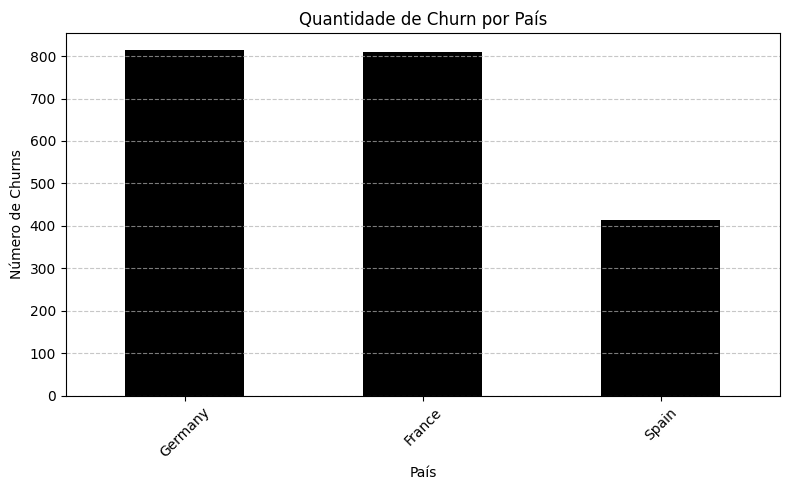

In [18]:
churn_df = df[df["Exited"] == 1]

churn_por_pais = churn_df["Geography"].value_counts()


plt.figure(figsize=(8, 5))
churn_por_pais.plot(kind="bar", color="black")

plt.title("Quantidade de Churn por País")
plt.xlabel("País")
plt.ylabel("Número de Churns")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [19]:
# Tratando as features presentes em `Geography` para que estejam 
# em sua forma numérica e não mais categórica. Escolhi, para tanto 
# adotar o one-hot-encoding, com remoção de uma feature. Dessa forma 
# entende-se que caso Germany e Spain sejam 0, o conjunto de features
# de um cliente qualquer irá se referir a alguém oriundo da França.

df = pd.get_dummies(df, columns=['Geography'], prefix='Geo', drop_first=True)

df["Geo_Germany"] = df["Geo_Germany"].map({True: 1, False: 0})
df["Geo_Spain"] = df["Geo_Spain"].map({True: 1, False: 0})

df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geo_Germany,Geo_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


### Análise de Dados

In [20]:
"""
O nível de churn está assimétrico entre si - o que é bom. 
Nesse sentido, adotar a acurácia para avaliar a performance dos modelos
de ML se torna contraproducente.  
"""

df.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

<Axes: >

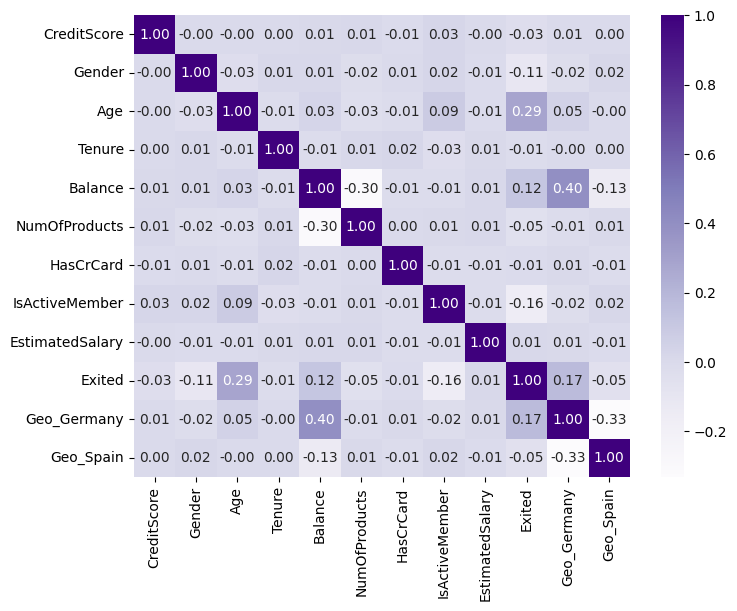

In [21]:
corr_matrix = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="Purples", fmt=".2f")

Analisando a matriz de Pearson, nota-se que há uma certa correlação linear entre as features relativas aos países e a ocorrência de churn, de modo que Germany apresenta uma correlação positiva enquanto que Spain levemente negativa. Dado que no gráfico de barras acima, France e Germany estavam com nível de churn parecidos, pode-se deduzir que há também uma correlação positiva desse país em relação ao nível de churn. 

In [22]:
def boxplot(
          dataset: DataFrame, 
          style : str, 
          height : int, 
          width : int
      ):
      
      """ 
      Generates a series of boxplots for each feature in the provided dataset.

      This function uses Seaborn and Matplotlib to create boxplots for all columns in the dataset. 
      The visual style of the plots is set using the provided style parameter. The plots are arranged 
      in a grid layout with 2 rows and 3 columns, and the figure size is determined by the height and 
      width parameters.

      Args:
        dataset (DataFrame): The dataset containing the features to be visualized.
        style (str): The Seaborn style theme to be applied to the plots (e.g., "darkgrid", "whitegrid").
        height (int): The height of the overall figure.
        width (int): The width of the overall figure.

      Returns:
        None: This function displays the boxplots directly using Matplotlib's `plt.show()`.
      """
      sns.set_theme(style=style)
    
      features = dataset.select_dtypes(include='number').columns
      total = len(features)

      cols = 3  # você pode ajustar esse valor conforme quiser
      rows = math.ceil(total / cols)

      plt.figure(figsize=(width, height))

      for i, feature in enumerate(features, 1):
          plt.subplot(rows, cols, i)
          sns.boxplot(y=dataset[feature])

      plt.tight_layout()
      plt.show()

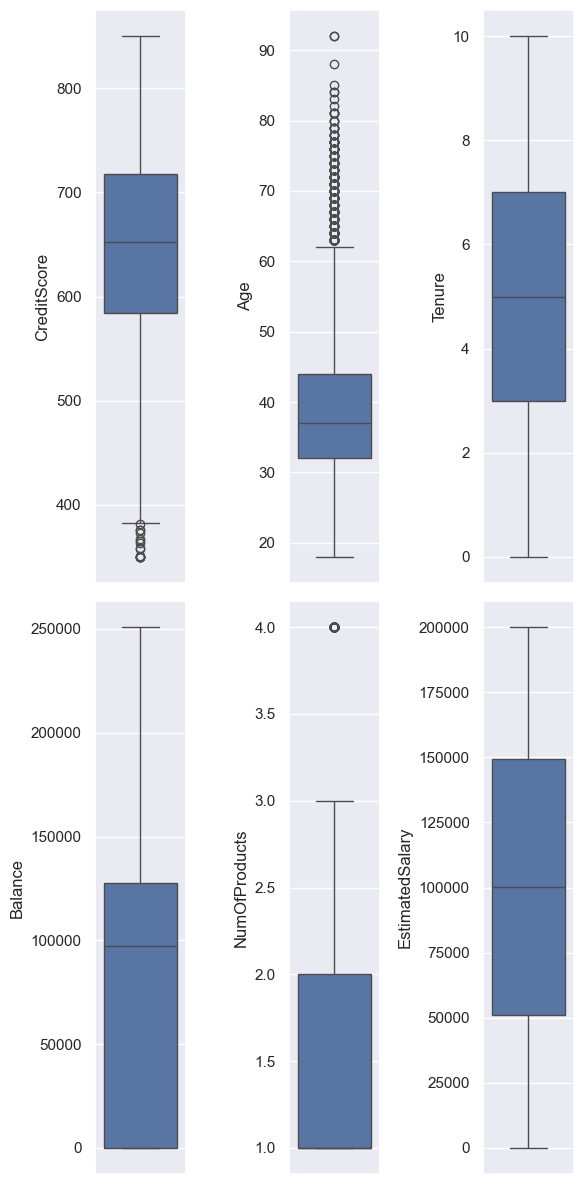

In [23]:
boxplot(
    dataset = df.drop(["Gender", "Geo_Germany", 
                       "Geo_Spain", "Exited", 
                       "HasCrCard", "IsActiveMember"], axis=1), 
    style   = "darkgrid", 
    height  = 12, 
    width   = 6
)

In [24]:
# Verificando a distribuição dos dados

def data_distribuition(
        dataset: DataFrame, 
        style : str, 
        height: int, 
        width: int, 
        bins: int
        ):
    """ 
    Visualizes the distribution of each feature in the dataset using histograms.

    Parameters:
    ----------
    dataset : DataFrame
        The dataset to be visualized, where each column represents a feature.
    
    style : str
        Seaborn theme for plot styling (e.g., 'darkgrid', 'whitegrid').
    
    height : int
        The height of the figure in inches.
    
    width : int
        The width of the figure in inches.
    
    bins : int
        Number of bins for the histograms.
    """
    feature = dataset.columns
    sns.set_theme(style=style)

    # Determinar o número de linhas no grid :
    
    # Fixo para 3 colunas
    n_cols = 3 

    # Calcular o número de linhas necessárias
    n_rows = (len(feature) + n_cols - 1) // n_cols  

    plt.figure(figsize=(height, width))

    for i, feature in enumerate(feature, 1):

        data = dataset[feature]

        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data, kde=True, bins=bins)
        plt.title(f"Histograma de {feature}")


    plt.tight_layout()
    plt.show()

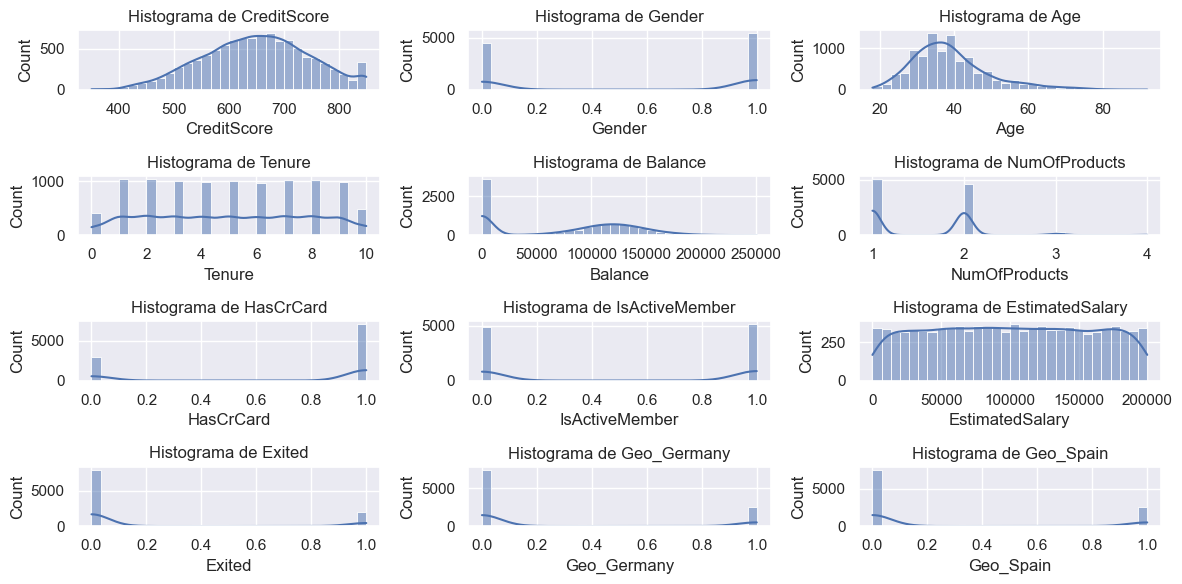

In [25]:
data_distribuition(
    dataset = df,
    style   = "darkgrid", 
    height  = 12, 
    width   = 6, 
    bins    = 30
)

In [26]:
def plot_bar_churn_relations(df):
    """
    Generates bar charts to visualize the relationship between selected features 
    and the churn label (`Exited`) in a customer dataset.

    The function creates a 2x2 grid of plots using Matplotlib:
        1. Average Age by churn status.
        2. Gender distribution stacked by churn.
        3. Average Balance by churn status.
        4. Proportion of churn based on Active Membership.

    Args:
        df (DataFrame): A Pandas DataFrame containing the customer dataset. 
                        Must include the following columns: 'Age', 'Gender', 
                        'Balance', 'IsActiveMember', and 'Exited'.

    Returns:
        None: The function displays the plots directly using Matplotlib.
    """
        
    # Define o estilo do gráfico
    plt.style.use('ggplot')

    # Inicializa a figura
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Relação entre variáveis e churn (Exited)', fontsize=16)


    # Age x Exited (média da idade por churn)
    age_churn = df.groupby('Exited')['Age'].mean()
    axs[0, 0].bar(age_churn.index.astype(str), age_churn.values, color=['skyblue', 'salmon'])
    axs[0, 0].set_title('Idade Média por Churn')
    axs[0, 0].set_xlabel('Exited')
    axs[0, 0].set_ylabel('Idade Média')


    # Gender x Exited (percentual por gênero)
    gender_churn = pd.crosstab(df['Gender'], df['Exited'], normalize='index')
    gender_churn.plot(kind='bar', stacked=True, ax=axs[0, 1], color=['skyblue', 'salmon'])
    axs[0, 1].set_title('Churn por Gênero')
    axs[0, 1].set_ylabel('Proporção')
    axs[0, 1].legend(title='Exited', labels=['Não', 'Sim'])

    
    # Balance x Exited (média do saldo)
    balance_churn = df.groupby('Exited')['Balance'].mean()
    axs[1, 0].bar(balance_churn.index.astype(str), balance_churn.values, color=['skyblue', 'salmon'])
    axs[1, 0].set_title('Balance por Churn')
    axs[1, 0].set_xlabel('Exited')
    axs[1, 0].set_ylabel('Balance')


    # Is Active Member x Exited (contagem cruzada)
    active_churn = pd.crosstab(df['IsActiveMember'], df['Exited'], normalize='index')
    active_churn.plot(kind='bar', stacked=True, ax=axs[1, 1], color=['skyblue', 'salmon'])
    axs[1, 1].set_title('Churn por Membro Ativo')
    axs[1, 1].set_ylabel('Proporção')
    axs[1, 1].set_xlabel('É Ativo?')
    axs[1, 1].legend(title='Exited', labels=['Não', 'Sim'])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

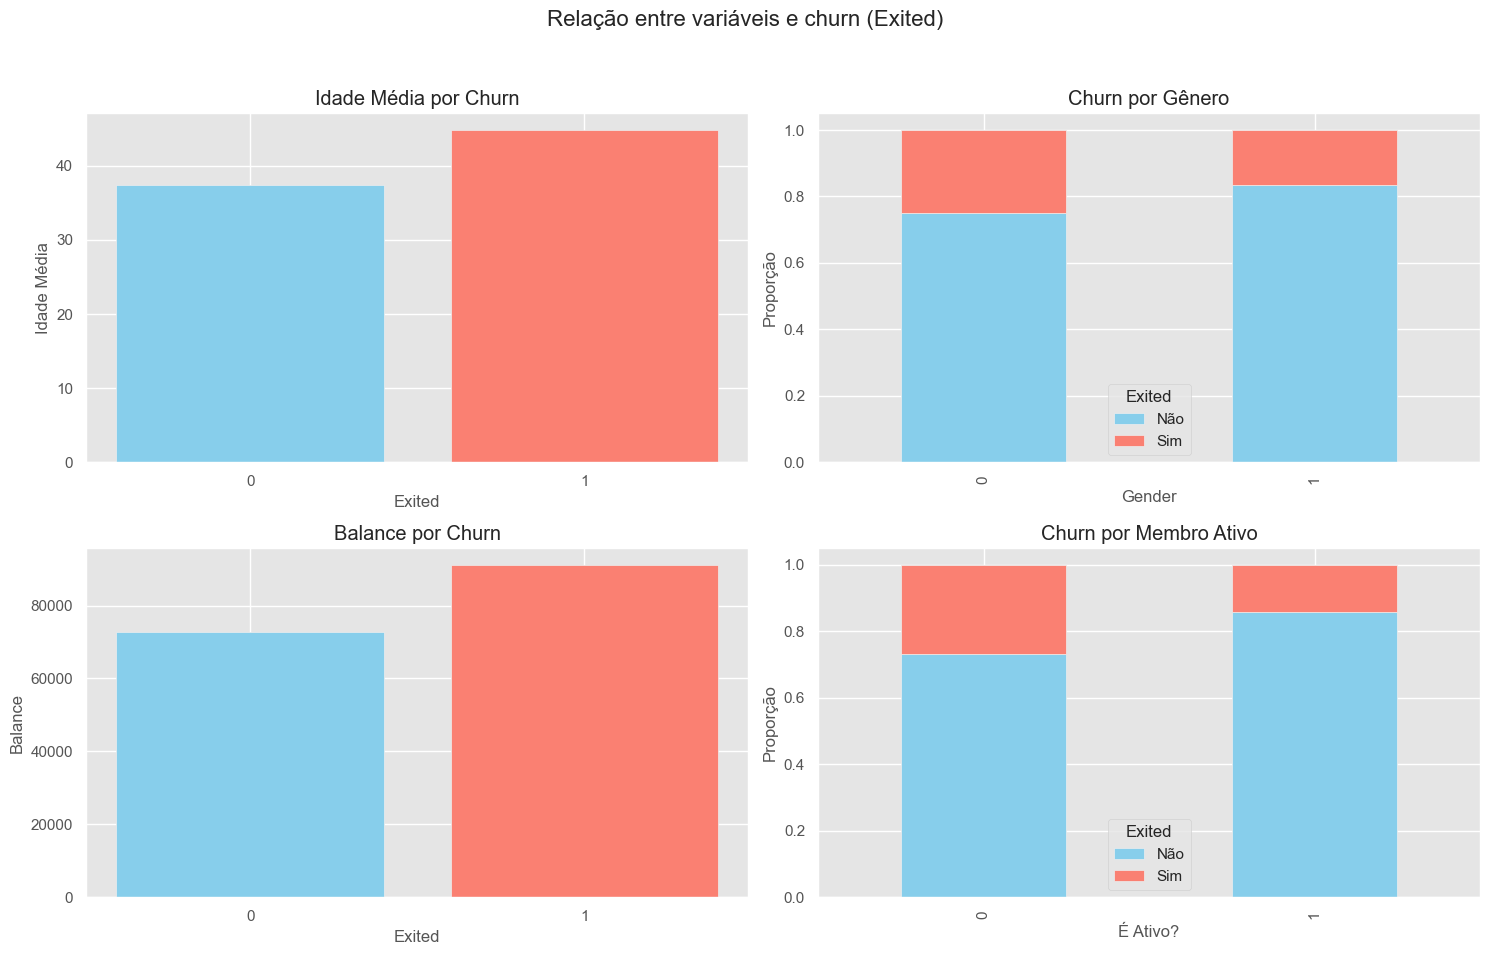

In [27]:
plot_bar_churn_relations(df=df)

In [28]:
def plot_age_bins_vs_churn(df, bins=None):
    """
    Creates a bar plot showing the churn rate (`Exited`) for each age group (binned).
    
    Args:
        df (DataFrame): Dataset containing at least the columns 'Age' and 'Exited'.
        bins (list or None): Optional list of bin edges to define age intervals. 
                             If None, default bins are used.
                             
    Returns:
        None: Displays the bar plot using matplotlib.
    """
    if bins is None:
        # Define default age bins (you can customize these)
        bins = [18, 25, 35, 45, 55, 65, 80]

    # Cria grupos etários
    df['AgeGroup'] = pd.cut(df['Age'], bins=bins)

    # Calcula taxa de churn por faixa etária
    churn_by_age = df.groupby('AgeGroup')['Exited'].mean()

    # Plota o gráfico de barras
    plt.figure(figsize=(10, 6))
    churn_by_age.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('Taxa de Churn por Faixa Etária')
    plt.xlabel('Faixa Etária')
    plt.ylabel('Proporção de Churn')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Remove coluna auxiliar para não alterar df original fora da função
    df.drop(columns='AgeGroup', inplace=True)

C:\Users\Bruno\AppData\Local\Temp\ipykernel_31388\406890459.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_age = df.groupby('AgeGroup')['Exited'].mean()


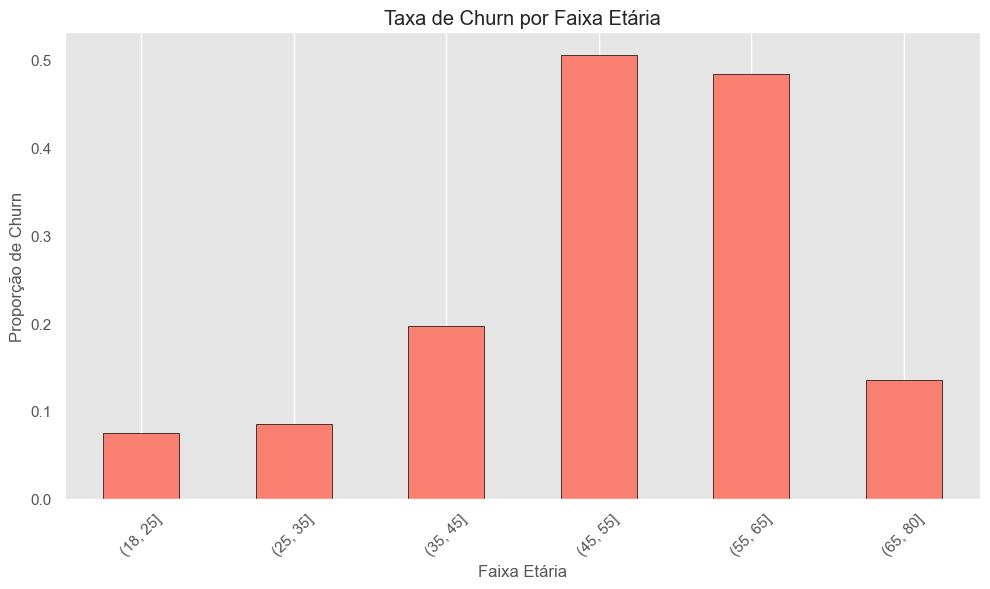

In [29]:
plot_age_bins_vs_churn(df=df)

In [30]:
def plot_balance_bins_vs_churn(df, bins=None):
    """
    Creates a bar plot showing the churn rate (`Exited`) for each balance group (binned).
    
    Args:
        df (DataFrame): Dataset containing at least the columns 'Balance' and 'Exited'.
        bins (list or None): Optional list of bin edges to define balance intervals. 
                             If None, default bins are used.
                             
    Returns:
        None: Displays the bar plot using matplotlib.
    """
    if bins is None:
        # Define default balance bins (customize conforme o seu dataset)
        bins = [0, 10000, 50000, 100000, 150000, 200000, 250000]

    # Cria grupos de saldo
    df['BalanceGroup'] = pd.cut(df['Balance'], bins=bins)

    # Calcula taxa de churn por grupo de saldo
    churn_by_balance = df.groupby('BalanceGroup')['Exited'].mean()

    # Plota o gráfico de barras
    plt.figure(figsize=(10, 6))
    churn_by_balance.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('Taxa de Churn por Faixa de Saldo')
    plt.xlabel('Faixa de Saldo')
    plt.ylabel('Proporção de Churn')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Remove a coluna temporária
    df.drop(columns='BalanceGroup', inplace=True)

C:\Users\Bruno\AppData\Local\Temp\ipykernel_31388\3834864695.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_balance = df.groupby('BalanceGroup')['Exited'].mean()


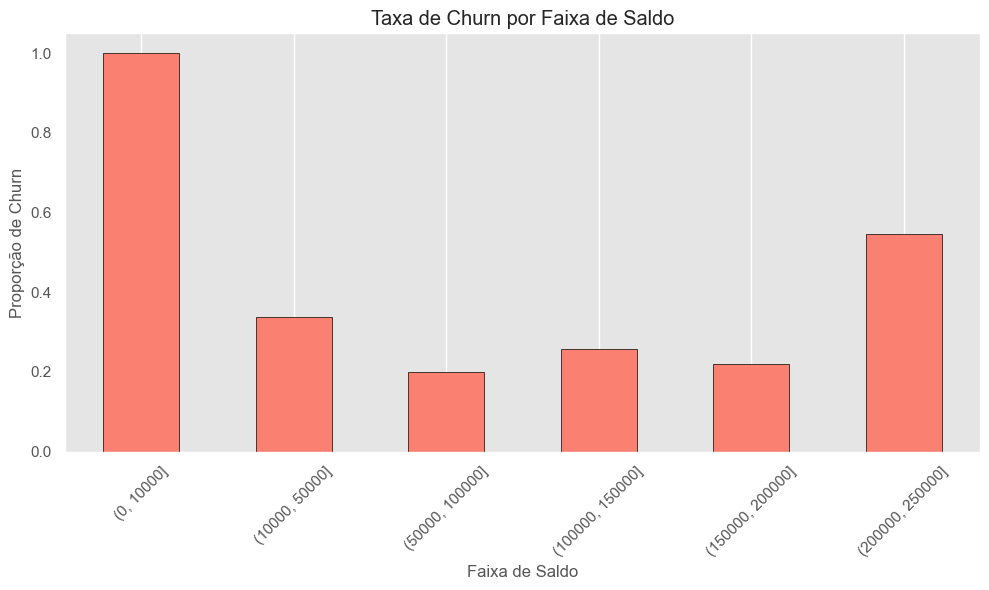

In [31]:
plot_balance_bins_vs_churn(df=df)

Analisando os diferentes gráficos, compreende-se que a informação geográfica pode ser um feature importante para compreender se um cliente tem maior probabilidade de incorrer a um cenário de churn ou não, devido a identificação de uma correlação linear identificada por meio da matriz de Pearson, bem como do gráfico de barras elaborado. 

Ao mesmo tempo, nota-se uma diferença de comportamento em relação ao gênero - na forma em que o gênero feminino tem um percentual de churn maior em relação aos homens -, bem como em consideração ao cliente estar econômicamente ativo ou não. Complementando, notou-se maior incidência de churn em pessoas de maior faixa etária e de menor renda identificada. Tais considerações são importantes, pois permitem identificar usuários em grupos particulares e compreender a partir desses quais são as features relativa a eles que se relacionam à incidência de churn. 

### Data Prep. 

Nessa parte será realizado à preparação dos dados para que possam ser informados aos algoritmos de ML. Por mais que boa parte da preparação dos dados já fora realizada, falta tratar os outliers identificados. Devido à acentuada assimetria observada, o método de tratamento será a `winsorização`, na qual substitui-se os valores tidos como outliers pelos limites superiores e inferiores da distribuição, respectivamente. 


In [32]:
def apply_winsorization(df, feature, lower_pct, upper_pct):
    """
    Applies winsorization to a given feature of the DataFrame.
    
    Args:
        df (DataFrame): Dataset containing the feature.
        feature (str): Name of the feature to winsorize.
        lower_pct (float): Proportion to cap from the lower end (e.g., 0.05 = 5%).
        upper_pct (float): Proportion to cap from the upper end.
    
    Returns:
        Series: The winsorized feature.
    """
    winsorized = winsorize(df[feature], limits=(lower_pct, upper_pct))
    return pd.Series(winsorized, index=df.index)

In [33]:
# CreditScore
df['CreditScore'] = apply_winsorization(df, 'CreditScore', lower_pct=0.05, upper_pct=0.01)

# Age
df['Age'] = apply_winsorization(df, 'Age', lower_pct=0.01, upper_pct=0.05)

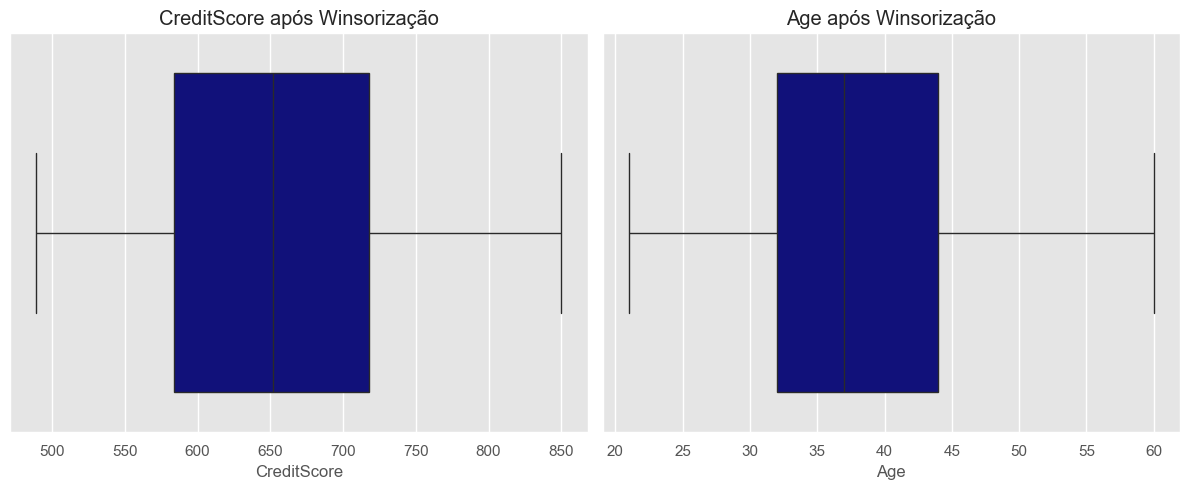

In [34]:
""" 
Verificando a ausência de outliers
"""

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=df['CreditScore'], ax=axs[0], color="darkblue")
axs[0].set_title('CreditScore após Winsorização')

sns.boxplot(x=df['Age'], ax=axs[1], color="darkblue")
axs[1].set_title('Age após Winsorização')

plt.tight_layout()
plt.show()

In [35]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geo_Germany,Geo_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


A estratégia de treinamento do modelo será a Hold-out. Nesse sentido, definirei um percentual de treinamento e de teste do dataset, realizando depois a normalização dos dados antes desses serem passados para os algortimos de ML. A normalização dos dados se dará em relação às variáveis contínuas - `balance`, `estimated salary` e `credit score` -, com o objetivo de colocá-las numa mesma distribuição para contribuir positivamente com a precisão dos modelos de ML. Para fins de redução a ocorrência de `data leakage`, a normalização será realizada depois da segmentação dos dados em treino e teste. 

In [36]:
SEED = 15

X = df.drop("Exited", axis=1)
y = df["Exited"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=SEED,
                                                    shuffle=True)

In [38]:
X_train.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geo_Germany,Geo_Spain
939,724,0,37,10,68598.56,1,1,0,157862.82,0,0
164,683,1,29,0,133702.89,1,1,0,55582.54,0,1
6261,708,0,35,8,122570.69,1,0,0,199005.88,0,1
4029,501,1,27,4,95331.83,2,1,0,132104.76,1,0
7061,603,0,35,9,145623.36,1,1,0,163181.62,1,0


In [39]:
scaler = StandardScaler()

features_to_normalize = ['CreditScore', 'Balance', 'EstimatedSalary']
normalized_values = scaler.fit_transform(X_train[features_to_normalize])

X_train_normalized = pd.DataFrame(
    normalized_values,
    columns = features_to_normalize,
    index   = X_train.index # preserva o índice original
)

X_train_rest = X_train.drop(columns=features_to_normalize)
X_train = pd.concat([X_train_normalized, X_train_rest], axis=1)

X_train.head()

,CreditScore,Balance,EstimatedSalary,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Geo_Germany,Geo_Spain
939,0.768217,-0.138579,1.008335,0,37,10,1,1,0,0,0
164,0.328060,0.906835,-0.773010,1,29,0,1,1,0,0,1
6261,0.596449,0.728080,1.724895,0,35,8,1,0,0,0,1
4029,-1.625806,0.290691,0.559725,1,27,4,2,1,0,1,0
7061,-0.530782,1.098248,1.100969,0,35,9,1,1,0,1,0


In [54]:
y_train.head()

939     0
164     1
6261    0
4029    0
7061    0
Name: Exited, dtype: int64

In [41]:
scaler = StandardScaler()

features_to_normalize = ['CreditScore', 'Balance', 'EstimatedSalary']
normalized_values = scaler.fit_transform(X_test[features_to_normalize])

X_test_normalized = pd.DataFrame(
    normalized_values,
    columns = features_to_normalize,
    index   = X_test.index # preserva o índice original
)

X_test_rest = X_test.drop(columns=features_to_normalize)
X_test = pd.concat([X_test_normalized, X_test_rest], axis=1)

X_test.head()

,CreditScore,Balance,EstimatedSalary,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Geo_Germany,Geo_Spain
522,-1.334531,0.321905,0.665519,1,37,5,2,1,1,0,1
5667,0.219867,-1.171043,-1.457530,0,34,8,2,1,1,0,0
4030,-0.519812,-1.171043,-0.175344,0,42,6,1,1,1,0,1
3198,-1.152291,0.365687,-1.123891,1,23,1,1,1,0,0,0
2902,0.423547,0.872809,0.224608,0,33,1,1,1,1,0,0


In [42]:
y_test.head()

522     0
5667    0
4030    0
3198    0
2902    0
Name: Exited, dtype: int64

### Random Forest

In [ ]:
def rf_objective(trial):
    """ 
    """
    rf = RandomForestClassifier(
        n_estimators       = trial.suggest_int("n_estimators", 50, 300),
        criterion          = trial.suggest_categorical("criterion", ["gini", "entropy"]),
        class_weight       = "balanced",
        max_depth          = trial.suggest_int("max_depth", 3, 20),
        min_samples_split  = trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf   = trial.suggest_int("min_samples_leaf", 1, 10),
        random_state       = SEED
    )

    scoring = {
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score),
        'roc_auc': 'roc_auc'
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_validate(rf, X_train, y_train, scoring=scoring, cv=cv)
    return scores['test_f1'].mean()

In [68]:
%%time

rf_study = optuna.create_study(direction="maximize", study_name="RandomForest")
rf_study.optimize(rf_objective, n_trials=50)

print("Melhor f1-score (RF):", rf_study.best_value)
print("Melhores hiperparâmetros (RF):", rf_study.best_params)

[I 2025-04-06 16:07:30,396] A new study created in memory with name: RandomForest
[I 2025-04-06 16:07:38,835] Trial 0 finished with value: 0.6173313541883433 and parameters: {'n_estimators': 281, 'criterion': 'entropy', 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.6173313541883433.
[I 2025-04-06 16:07:46,415] Trial 1 finished with value: 0.6193295908689292 and parameters: {'n_estimators': 224, 'criterion': 'gini', 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.6193295908689292.
[I 2025-04-06 16:07:49,131] Trial 2 finished with value: 0.6221404485646819 and parameters: {'n_estimators': 103, 'criterion': 'gini', 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 2 with value: 0.6221404485646819.
[I 2025-04-06 16:07:57,979] Trial 3 finished with value: 0.6210205777457853 and parameters: {'n_estimators': 254, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_sp

Melhor f1-score (RF): 0.6284462744730563
Melhores hiperparâmetros (RF): {'n_estimators': 184, 'criterion': 'entropy', 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 7}
CPU times: total: 5min 16s
Wall time: 5min 20s


### Logistic Regression 

In [ ]:
def logreg_objective(trial):
    """ 
    """
    pipeline = Pipeline([
        ('logreg', LogisticRegression(
            C              = trial.suggest_loguniform("C", 1e-4, 1e2),
            penalty        = trial.suggest_categorical("penalty", ["l1", "l2"]),
            solver         = trial.suggest_categorical("solver", ["liblinear", "saga"]),
            class_weight   = "balanced",
            max_iter       = 1000,
            random_state   = SEED
            )
        )
    ])

    scoring = {
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score),
        'roc_auc': 'roc_auc'
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_validate(pipeline, X_train, y_train, scoring=scoring, cv=cv)
    return scores['test_f1'].mean()


In [66]:
%%time

logreg_study = optuna.create_study(direction="maximize", study_name="LogisticRegression")
logreg_study.optimize(logreg_objective, n_trials=50)

print("Melhor f1-score (LogReg):", logreg_study.best_value)
print("Melhores hiperparâmetros (LogReg):", logreg_study.best_params)

[I 2025-04-06 16:06:18,613] A new study created in memory with name: LogisticRegression
[I 2025-04-06 16:06:20,058] Trial 0 finished with value: 0.49989360630177815 and parameters: {'C': 7.681766641794923, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 0 with value: 0.49989360630177815.
[I 2025-04-06 16:06:21,136] Trial 1 finished with value: 0.5002226248807984 and parameters: {'C': 1.0833862148287323, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 1 with value: 0.5002226248807984.
[I 2025-04-06 16:06:21,359] Trial 2 finished with value: 0.4293603365756874 and parameters: {'C': 0.004450434694266103, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 1 with value: 0.5002226248807984.
[I 2025-04-06 16:06:21,671] Trial 3 finished with value: 0.5006636689585074 and parameters: {'C': 0.25702146538593296, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 3 with value: 0.5006636689585074.
[I 2025-04-06 16:06:21,801] Trial 4 finished with value: 0.5011114613653254 and parameters

Melhor f1-score (LogReg): 0.5106363877888965
Melhores hiperparâmetros (LogReg): {'C': 0.007474699067750526, 'penalty': 'l2', 'solver': 'saga'}
CPU times: total: 41.2 s
Wall time: 45.5 s


### Analisando as métricas do Random Forest

In [69]:
best_rf = RandomForestClassifier(**rf_study.best_params, random_state=SEED)
best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1596
           1       0.79      0.42      0.54       404

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000



In [78]:
importances = best_rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
4,Age,0.308279
6,NumOfProducts,0.198836
1,Balance,0.119515
2,EstimatedSalary,0.091685
0,CreditScore,0.089721
8,IsActiveMember,0.061326
5,Tenure,0.051888
9,Geo_Germany,0.034762
3,Gender,0.022284
7,HasCrCard,0.011204


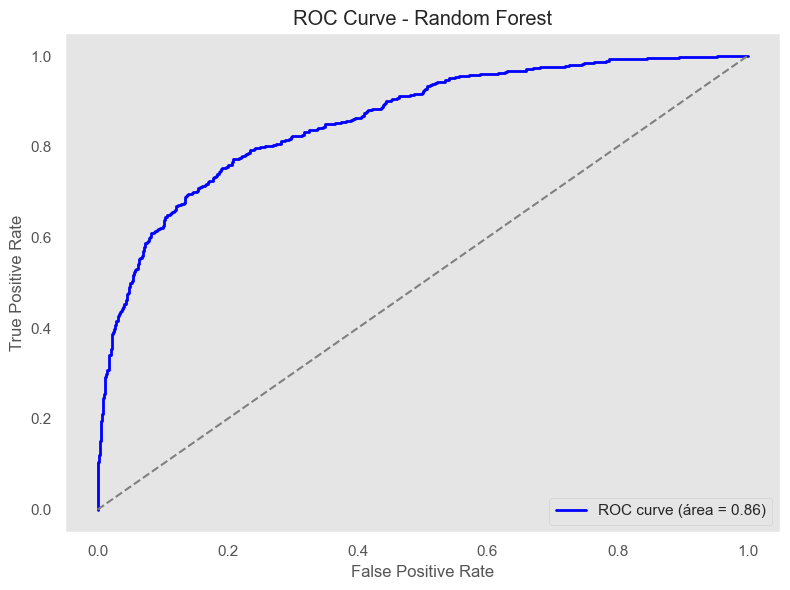

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)
roc_auc = auc(fpr, tpr)

# Plotar a curva ROC

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()

### Analisando as métricas para a Regressão Logística

In [75]:
best_rgloss = LogisticRegression(**logreg_study.best_params, random_state=SEED)
best_rgloss.fit(X_train, y_train)

y_pred_rgloss = best_rgloss.predict(X_test)
y_proba_rgloss = best_rgloss.predict_proba(X_test)[:, 1]

print("Regression Logistic - Classification Report:")
print(classification_report(y_test, y_pred_rgloss))


Regression Logistic - Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      1596
           1       0.77      0.19      0.30       404

    accuracy                           0.82      2000
   macro avg       0.80      0.59      0.60      2000
weighted avg       0.82      0.82      0.78      2000



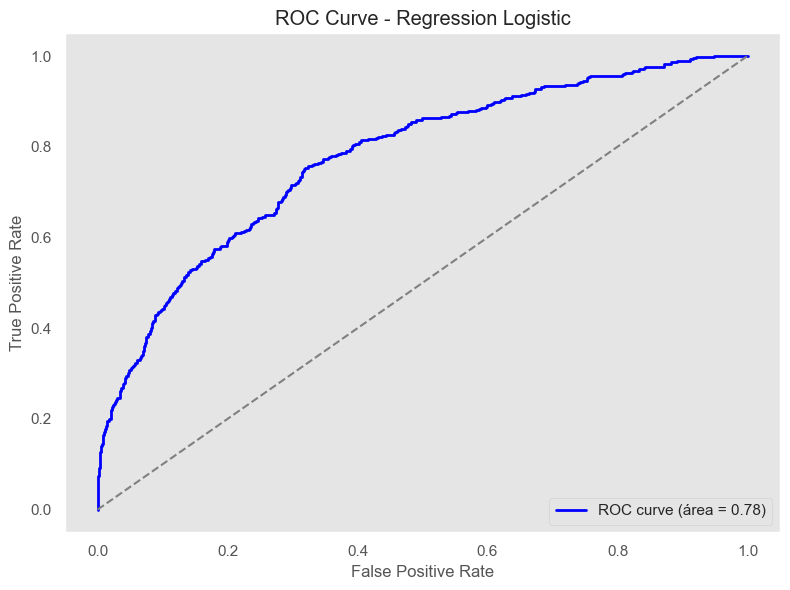

In [76]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rgloss)
roc_auc = auc(fpr, tpr)

# Plotar a curva ROC

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Regression Logistic')
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()

### Considerando os modelos

Analisando ambos os modelos, nota-se que o Random Forest consegue se ajustar melhor do que o modelo de regressão logística. Isso pode ser verificado segundo as métricas evidenciadas, tais como f1-score e a curva ROC. Um dos motivos para isso pode se dar pelos dados não apresentar uma relação linear em relação à label, verificado por meio da matriz de Pearson, tendo em vista que tal modelo tende a melhor se ajustar para dados que apresentam tal distribuição. 